<a href="https://colab.research.google.com/github/juliosdutra/FundamentosComputacionais/blob/main/monitoramento_tanque.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monitoramento de nível de tanque



## Problema

Monitorar o nível de um tanque:

- Alerta se nível < 10.0 m
- Alerta se nível > 90.0 m
- Caso contrário: operação segura

Também deve tratar erros de leitura (sensor inválido).

## Fluxograma (Graphviz)

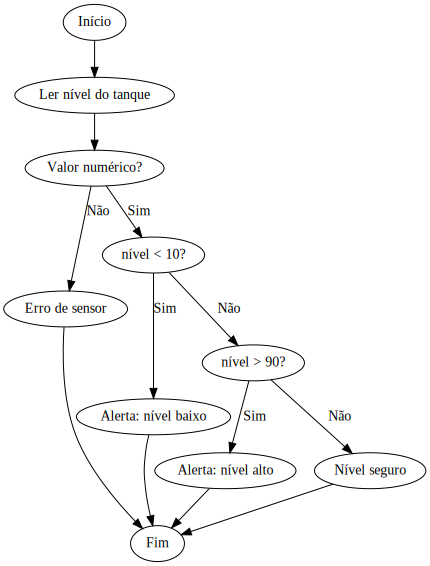

In [ ]:
from graphviz import Digraph

# =========================
# Criação do objeto do fluxograma
# =========================
g = Digraph()

# =========================
# Definição dos nós (etapas do algoritmo)
# =========================
g.node('A', 'Início')
g.node('B', 'Ler nível do tanque')
g.node('C', 'Valor numérico?')      # validação da leitura
g.node('D', 'Erro de sensor')       # tratamento de falha
g.node('E', 'nível < 10?')          # limite inferior
g.node('F', 'Alerta: nível baixo')
g.node('G', 'nível > 90?')          # limite superior
g.node('H', 'Alerta: nível alto')
g.node('I', 'Nível seguro')
g.node('J', 'Fim')

# =========================
# Conexões (fluxo lógico)
# =========================
g.edge('A','B')
g.edge('B','C')

# Decisão: leitura válida?
g.edge('C','D', label='Não')  # erro
g.edge('C','E', label='Sim')  # segue análise

# Decisão: abaixo do limite?
g.edge('E','F', label='Sim')
g.edge('E','G', label='Não')

# Decisão: acima do limite?
g.edge('G','H', label='Sim')
g.edge('G','I', label='Não')

# Encerramento (todos os caminhos levam ao fim)
g.edge('D','J')
g.edge('F','J')
g.edge('H','J')
g.edge('I','J')

# Exibe o fluxograma
g

In [ ]:
# Salva o arquivo
g.render('fluxograma_tanque', view=True)

'fluxograma_tanque.pdf'

## Versão com `if/elif/else` e `try/except`

Foi considerada uma separação entre:
* validação
* decisão
* resposta

> Esse padrão é praticamente um “esqueleto” de lógica industrial:
>  (`sensor → verificação → ação`).

In [11]:
# =========================
# Definição dos limites operacionais seguros (em metros)
# =========================
nivel_min = 10.0   # limite inferior de segurança
nivel_max = 90.0   # limite superior de segurança

# =========================
# Simulação da leitura do sensor
# Pode ser:
# - valor numérico (ok)
# - None (falha)
# - string (erro de tipo)
# =========================
nivel_tanque = 25.0  # teste proposital de erro

try:
    # =========================
    # Validação do tipo de dado
    # Garante que o valor seja numérico (int ou float)
    # =========================
    if not isinstance(nivel_tanque, (int, float)):
        raise ValueError('Leitura inválida do sensor')

    # =========================
    # Estrutura condicional
    # Avalia o estado do tanque
    # =========================
    if nivel_tanque < nivel_min:
        mensagem = 'ALERTA: nível ABAIXO do limite seguro'

    elif nivel_tanque > nivel_max:
        mensagem = 'ALERTA: nível ACIMA do limite seguro'

    else:
        mensagem = 'Nível dentro da faixa segura'

# =========================
# Tratamento de exceções
# Captura falhas na leitura do sensor
# =========================
except ValueError as e:
    mensagem = f'FALHA DE SENSOR: {e}'

# =========================
# Saída do sistema
# =========================
print(mensagem)

Nível dentro da faixa segura


In [12]:
from IPython.display import display, HTML

def mostrar_status_box(mensagem):
    if "ABAIXO" in mensagem or "ACIMA" in mensagem:
        cor = "#fff3cd"
        borda = "#ffa500"
    elif "FALHA" in mensagem:
        cor = "#f8d7da"
        borda = "#dc3545"
    else:
        cor = "#d4edda"
        borda = "#28a745"

    display(HTML(f"""
    <div style="
        background-color: {cor};
        border-left: 6px solid {borda};
        padding: 10px;
        font-weight: bold;">
        {mensagem}
    </div>
    """))

# Teste
mostrar_status_box(mensagem)

In [17]:
from IPython.display import display, HTML

def mostrar_status_dashboard(nivel, nivel_min = 10, nivel_max = 90):

    # lógica
    if not isinstance(nivel, (int, float)):
        mensagem = "FALHA DE SENSOR"
        cor = "#f8d7da"
        borda = "#dc3545"
        percentual = 0
    elif nivel < nivel_min:
        mensagem = "NÍVEL BAIXO"
        cor = "#fff3cd"
        borda = "#ffa500"
        percentual = nivel
    elif nivel > nivel_max:
        mensagem = "NÍVEL ALTO"
        cor = "#fff3cd"
        borda = "#ffa500"
        percentual = nivel
    else:
        mensagem = "NÍVEL SEGURO"
        cor = "#d4edda"
        borda = "#28a745"
        percentual = nivel

    # barra limitada entre 0 e 100
    percentual = max(0, min(100, percentual))

    display(HTML(f"""
    <div style="
        background-color: {cor};
        border-left: 6px solid {borda};
        padding: 12px;
        font-weight: bold;
        width: 300px;">

        {mensagem}<br>
        Nível: {nivel}

        <div style="
            margin-top: 8px;
            background-color: #eee;
            height: 20px;">

            <div style="
                width: {percentual}%;
                height: 100%;
                background-color: {borda};">
            </div>
        </div>
    </div>
    """))

# Testes
mostrar_status_dashboard(5)
mostrar_status_dashboard(50)
mostrar_status_dashboard(95)
mostrar_status_dashboard(None)
mostrar_status_dashboard('abc')

## Versão usando `match/case`

Esse exemplo é interessante porque mostra:
* **pattern matching** (mais expressivo que if/elif)
* separação clara entre lógica de processo e tratamento de falha

Em aplicações industriais, esse tipo de estrutura ajuda a organizar múltiplos cenários de operação de forma mais legível.

In [ ]:
# =========================
# Definição dos limites operacionais
# =========================
nivel_min = 10.0   # limite inferior seguro
nivel_max = 90.0   # limite superior seguro

# =========================
# Simulação da leitura do sensor
# Pode ser:
# - número (válido)
# - None (sensor sem leitura)
# - outro tipo (erro)
# =========================
nivel_tanque = None  # teste de falha

try:
    # =========================
    # Estrutura match-case (Python 3.10+)
    # Permite tratar diferentes padrões de entrada
    # =========================
    match nivel_tanque:

        # Caso 1: valor numérico abaixo do limite mínimo
        case float(n) | int(n) if n < nivel_min:
            mensagem = "ALERTA: Nível ABAIXO do limite!"

        # Caso 2: valor numérico acima do limite máximo
        case float(n) | int(n) if n > nivel_max:
            mensagem = "ALERTA: Nível ACIMA do limite!"

        # Caso 3: valor numérico dentro da faixa segura
        case float(n) | int(n) if nivel_min <= n <= nivel_max:
            mensagem = "Nível do tanque dentro do limite."

        # Caso 4: leitura ausente (sensor retornou None)
        case None:
            raise ValueError("FALHA DE SENSOR: Leitura ausente.")

        # Caso 5: qualquer outro tipo inválido (string, lista, etc.)
        case _:
            raise ValueError("FALHA DE SENSOR: Leitura inválida.")

# =========================
# Tratamento de exceções
# Captura falhas e evita travamento do sistema
# =========================
except ValueError as e:
    mensagem = str(e)

# =========================
# Saída final do sistema
# =========================
print(mensagem)

FALHA DE SENSOR: Leitura ausente.
